# Objective

The goal of this data analysis project using sql would be to identify opportunities to increase the occupancy rate on low performing flights, which can ultimately lead to increase the profitability for the airlines

# Importing Libraries

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Database Connection

In [3]:
data_connect = sqlite3.connect("travel.sqlite")
cursor = data_connect.cursor()

In [4]:
tables = pd.read_sql("""SELECT * FROM sqlite_master WHERE type ='table'; """,data_connect)
tables

,type,name,tbl_name,rootpage,sql
0,table,aircrafts_data,aircrafts_data,2,CREATE TABLE aircrafts_data (\r\n aircraft_...
1,table,airports_data,airports_data,3,CREATE TABLE airports_data (\r\n airport_co...
2,table,boarding_passes,boarding_passes,4,CREATE TABLE boarding_passes (\r\n ticket_n...
3,table,bookings,bookings,5,CREATE TABLE bookings (\r\n book_ref charac...
4,table,flights,flights,6,CREATE TABLE flights (\r\n flight_id intege...
5,table,seats,seats,7,CREATE TABLE seats (\r\n aircraft_code char...
6,table,ticket_flights,ticket_flights,8,CREATE TABLE ticket_flights (\r\n ticket_no...
7,table,tickets,tickets,9,CREATE TABLE tickets (\r\n ticket_no charac...


# Data Exploration

In [5]:
# Reading Data within table [aircrafts_data]
aircraft_data = pd.read_sql(""" SELECT *
                                FROM aircrafts_data;""",data_connect)
aircraft_data

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600
5,319,"{""en"": ""Airbus A319-100"", ""ru"": ""Аэробус A319-...",6700
6,733,"{""en"": ""Boeing 737-300"", ""ru"": ""Боинг 737-300""}",4200
7,CN1,"{""en"": ""Cessna 208 Caravan"", ""ru"": ""Сессна 208...",1200
8,CR2,"{""en"": ""Bombardier CRJ-200"", ""ru"": ""Бомбардье ...",2700


In [6]:
# Reading Data within table [airports_data]
airports_data = pd.read_sql(""" SELECT *
                                FROM airports_data;""",data_connect)
airports_data

,airport_code,airport_name,city,coordinates,timezone
0,YKS,"{""en"": ""Yakutsk Airport"", ""ru"": ""Якутск""}","{""en"": ""Yakutsk"", ""ru"": ""Якутск""}","(129.77099609375,62.0932998657226562)",Asia/Yakutsk
1,MJZ,"{""en"": ""Mirny Airport"", ""ru"": ""Мирный""}","{""en"": ""Mirnyj"", ""ru"": ""Мирный""}","(114.03900146484375,62.534698486328125)",Asia/Yakutsk
2,KHV,"{""en"": ""Khabarovsk-Novy Airport"", ""ru"": ""Хабар...","{""en"": ""Khabarovsk"", ""ru"": ""Хабаровск""}","(135.18800354004,48.5279998779300001)",Asia/Vladivostok
3,PKC,"{""en"": ""Yelizovo Airport"", ""ru"": ""Елизово""}","{""en"": ""Petropavlovsk"", ""ru"": ""Петропавловск-К...","(158.453994750976562,53.1679000854492188)",Asia/Kamchatka
4,UUS,"{""en"": ""Yuzhno-Sakhalinsk Airport"", ""ru"": ""Хом...","{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахали...","(142.718002319335938,46.8886985778808594)",Asia/Sakhalin
...,...,...,...,...,...
99,MMK,"{""en"": ""Murmansk Airport"", ""ru"": ""Мурманск""}","{""en"": ""Murmansk"", ""ru"": ""Мурманск""}","(32.7508010864257812,68.7817001342773438)",Europe/Moscow
100,ABA,"{""en"": ""Abakan Airport"", ""ru"": ""Абакан""}","{""en"": ""Abakan"", ""ru"": ""Абакан""}","(91.3850021362304688,53.7400016784667969)",Asia/Krasnoyarsk
101,BAX,"{""en"": ""Barnaul Airport"", ""ru"": ""Барнаул""}","{""en"": ""Barnaul"", ""ru"": ""Барнаул""}","(83.5384979248046875,53.363800048828125)",Asia/Krasnoyarsk
102,AAQ,"{""en"": ""Anapa Vityazevo Airport"", ""ru"": ""Витяз...","{""en"": ""Anapa"", ""ru"": ""Анапа""}","(37.3473014831539984,45.002101898192997)",Europe/Moscow


In [7]:
# Reading Data within table [boarding_passes]
boarding_passes = pd.read_sql(""" SELECT *
                                FROM boarding_passes;""",data_connect)
boarding_passes

,ticket_no,flight_id,boarding_no,seat_no
0,0005435212351,30625,1,2D
1,0005435212386,30625,2,3G
2,0005435212381,30625,3,4H
3,0005432211370,30625,4,5D
4,0005435212357,30625,5,11A
...,...,...,...,...
579681,0005434302871,19945,85,20F
579682,0005432892791,19945,86,21C
579683,0005434302869,19945,87,20E
579684,0005432802476,19945,88,21F


In [8]:
# Reading Data within table [bookings]
bookings = pd.read_sql(""" SELECT *
                                FROM bookings;""",data_connect)
bookings

,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600
...,...,...,...
262783,FFFEF3,2017-07-17 07:23:00+03,56000
262784,FFFF2C,2017-08-08 05:55:00+03,10800
262785,FFFF43,2017-07-20 20:42:00+03,78500
262786,FFFFA8,2017-08-08 04:45:00+03,28800


In [9]:
# Reading Data within table [flights]
flights = pd.read_sql(""" SELECT *
                                FROM flights;""",data_connect)
flights

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
1,3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
2,4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
3,5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
4,6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N
...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03,2017-08-02 20:10:00+03,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03,2017-08-02 20:10:00+03
33117,33118,PG0063,2017-07-28 19:25:00+03,2017-07-28 20:10:00+03,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03,2017-07-28 20:15:00+03
33118,33119,PG0063,2017-09-08 19:25:00+03,2017-09-08 20:10:00+03,SKX,SVO,Scheduled,CR2,\N,\N
33119,33120,PG0063,2017-08-01 19:25:00+03,2017-08-01 20:10:00+03,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03,2017-08-01 20:12:00+03


In [10]:
# Reading Data within table [seats]
seats = pd.read_sql(""" SELECT *
                                FROM seats;""",data_connect)
seats

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business
...,...,...,...
1334,773,48H,Economy
1335,773,48K,Economy
1336,773,49A,Economy
1337,773,49C,Economy


In [11]:
# Reading Data within table [ticket_flights]
ticket_flights = pd.read_sql(""" SELECT *
                                FROM ticket_flights;""",data_connect)
ticket_flights

,ticket_no,flight_id,fare_conditions,amount
0,0005432159776,30625,Business,42100
1,0005435212351,30625,Business,42100
2,0005435212386,30625,Business,42100
3,0005435212381,30625,Business,42100
4,0005432211370,30625,Business,42100
...,...,...,...,...
1045721,0005435097522,32094,Economy,5200
1045722,0005435097521,32094,Economy,5200
1045723,0005435104384,32094,Economy,5200
1045724,0005435104352,32094,Economy,5200


In [12]:
# Reading Data within table [tickets]
tickets = pd.read_sql(""" SELECT *
                                FROM tickets;""",data_connect)
tickets

,ticket_no,book_ref,passenger_id
0,0005432000987,06B046,8149 604011
1,0005432000988,06B046,8499 420203
2,0005432000989,E170C3,1011 752484
3,0005432000990,E170C3,4849 400049
4,0005432000991,F313DD,6615 976589
...,...,...,...
366728,0005435999869,D730BA,0474 690760
366729,0005435999870,D730BA,6535 751108
366730,0005435999871,A1AD46,1596 156448
366731,0005435999872,7B6A53,9374 822707


In [13]:
# To get the list of all the table names from a DataFrame
table_names = tables['name'].tolist()

In [14]:
# To check if any null values present in any of the Tables
for table_name in table_names:
    print('\ntable:', table_name)
    df_table = pd.read_sql(f"SELECT * FROM {table_name}",data_connect)
    print(df_table.isnull().sum())


table: aircrafts_data
aircraft_code    0
model            0
range            0
dtype: int64

table: airports_data
airport_code    0
airport_name    0
city            0
coordinates     0
timezone        0
dtype: int64

table: boarding_passes
ticket_no      0
flight_id      0
boarding_no    0
seat_no        0
dtype: int64

table: bookings
book_ref        0
book_date       0
total_amount    0
dtype: int64

table: flights
flight_id              0
flight_no              0
scheduled_departure    0
scheduled_arrival      0
departure_airport      0
arrival_airport        0
status                 0
aircraft_code          0
actual_departure       0
actual_arrival         0
dtype: int64

table: seats
aircraft_code      0
seat_no            0
fare_conditions    0
dtype: int64

table: ticket_flights
ticket_no          0
flight_id          0
fare_conditions    0
amount             0
dtype: int64

table: tickets
ticket_no       0
book_ref        0
passenger_id    0
dtype: int64


In [15]:
# Checking for Duplicated Values 
for table_name in table_names:
    print(f'Table:',table_name)
    df_table_dup = pd.read_sql(f"SELECT * FROM {table_name}",data_connect)
    print(df_table_dup.duplicated().sum())

Table: aircrafts_data
0
Table: airports_data
0
Table: boarding_passes
0
Table: bookings
0
Table: flights
0
Table: seats
0
Table: ticket_flights
0
Table: tickets
0


# Basic Analysis 

##### How many planes have more than 100 seats?

In [16]:
pd.read_sql_query("""SELECT aircraft_code, count(*) as num_seats FROM seats
                            group by aircraft_code ORDER BY num_seats desc""",data_connect)

,aircraft_code,num_seats
0,773,402
1,763,222
2,321,170
3,320,140
4,733,130
5,319,116
6,SU9,97
7,CR2,50
8,CN1,12


##### How the number of tickets booked and total amount earned changed by time?

In [17]:
df_tickets = pd.read_sql_query("""SELECT * FROM tickets as T INNER JOIN bookings as B
                            ON T.book_ref = B.book_ref""",data_connect)

df_tickets['book_date'] = pd.to_datetime(df_tickets['book_date'])
df_tickets['date'] = df_tickets['book_date'].dt.date
df_tickets

,ticket_no,book_ref,passenger_id,book_ref,book_date,total_amount,date
0,0005432000987,06B046,8149 604011,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
1,0005432000988,06B046,8499 420203,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
2,0005432000989,E170C3,1011 752484,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
3,0005432000990,E170C3,4849 400049,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
4,0005432000991,F313DD,6615 976589,F313DD,2017-07-03 04:37:00+03:00,30900,2017-07-03
...,...,...,...,...,...,...,...
366728,0005435999869,D730BA,0474 690760,D730BA,2017-08-14 11:50:00+03:00,210600,2017-08-14
366729,0005435999870,D730BA,6535 751108,D730BA,2017-08-14 11:50:00+03:00,210600,2017-08-14
366730,0005435999871,A1AD46,1596 156448,A1AD46,2017-08-13 03:49:00+03:00,45900,2017-08-13
366731,0005435999872,7B6A53,9374 822707,7B6A53,2017-08-15 15:54:00+03:00,219400,2017-08-15


In [18]:
x = df_tickets.groupby('date')[['date']].count()
x.head()

,date
date,
2017-06-21,6
2017-06-22,12
2017-06-23,28
2017-06-24,106
2017-06-25,266


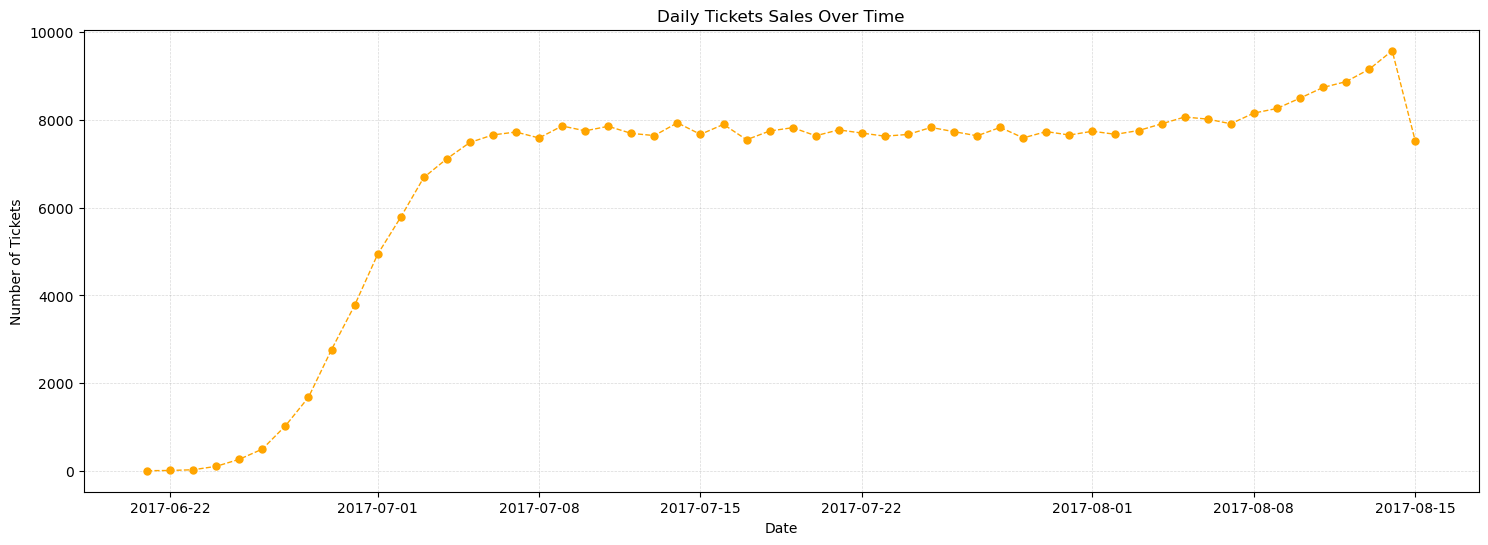

In [19]:
plt.figure(figsize=(18,6))
plt.plot(x.index,x['date'], marker='.', markersize=10 , linestyle='--', color='orange', linewidth=1)
plt.title('Daily Tickets Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tickets')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
plt.show()

In [20]:
df_bookings = pd.read_sql_query(""" SELECT *
                                FROM bookings;""",data_connect)
df_bookings['book_date']= pd.to_datetime(df_bookings['book_date'])
df_bookings['date']= df_bookings['book_date'].dt.date
x = df_bookings.groupby('date')[['total_amount']].sum()
x.head()

,total_amount
date,
2017-06-21,441900
2017-06-22,775300
2017-06-23,1822000
2017-06-24,5977000
2017-06-25,15305400


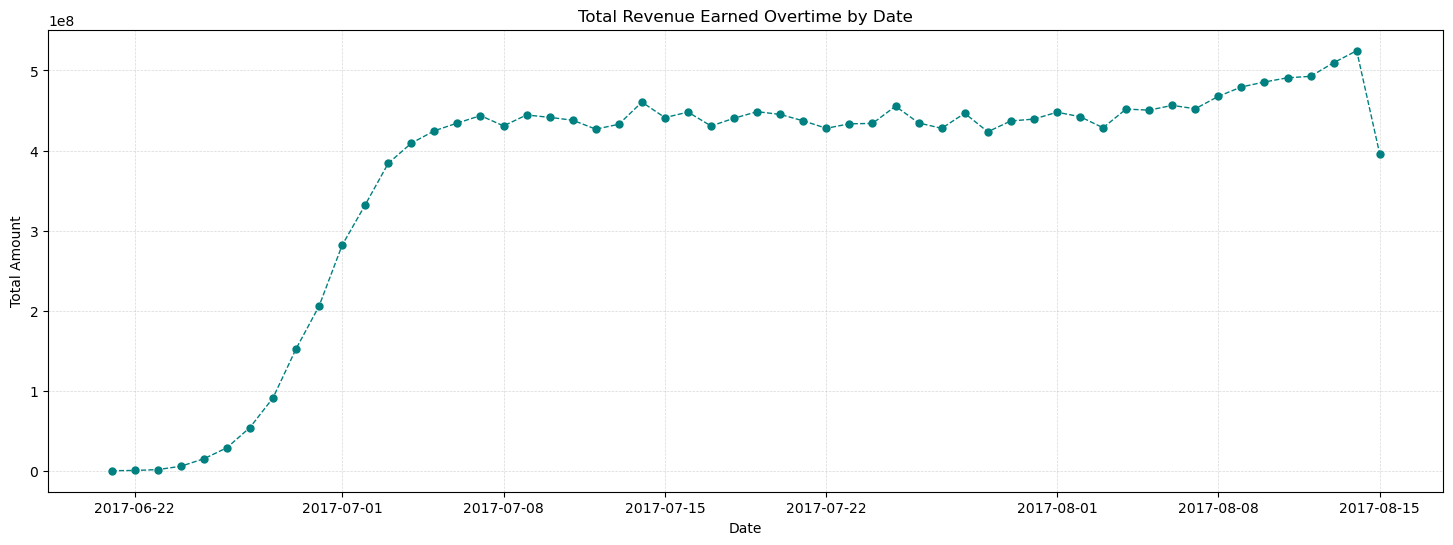

In [21]:
plt.figure(figsize=(18,6))
plt.plot(x.index,x['total_amount'], marker='.', markersize=10 , linestyle='--', color='teal', linewidth=1)
plt.title('Total Revenue Earned Overtime by Date')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
plt.show()

##### Calculate the average charges for each aircraft with different fare Conditions?

In [22]:
df_air_avg_charges = pd.read_sql_query("""SELECT fare_conditions, aircraft_code, avg(amount) 
                                        FROM ticket_flights as tf INNER JOIN flights as f
                                            on tf.flight_id = f.flight_id
                                                group by aircraft_code, fare_conditions""", data_connect)
df_air_avg_charges

,fare_conditions,aircraft_code,avg(amount)
0,Business,319,113550.557703
1,Economy,319,38311.402347
2,Business,321,34435.662664
3,Economy,321,11534.974764
4,Business,733,41865.626175
5,Economy,733,13985.152000
6,Business,763,82839.842866
7,Economy,763,27594.721829
8,Business,773,57779.909435
9,Comfort,773,32740.552889


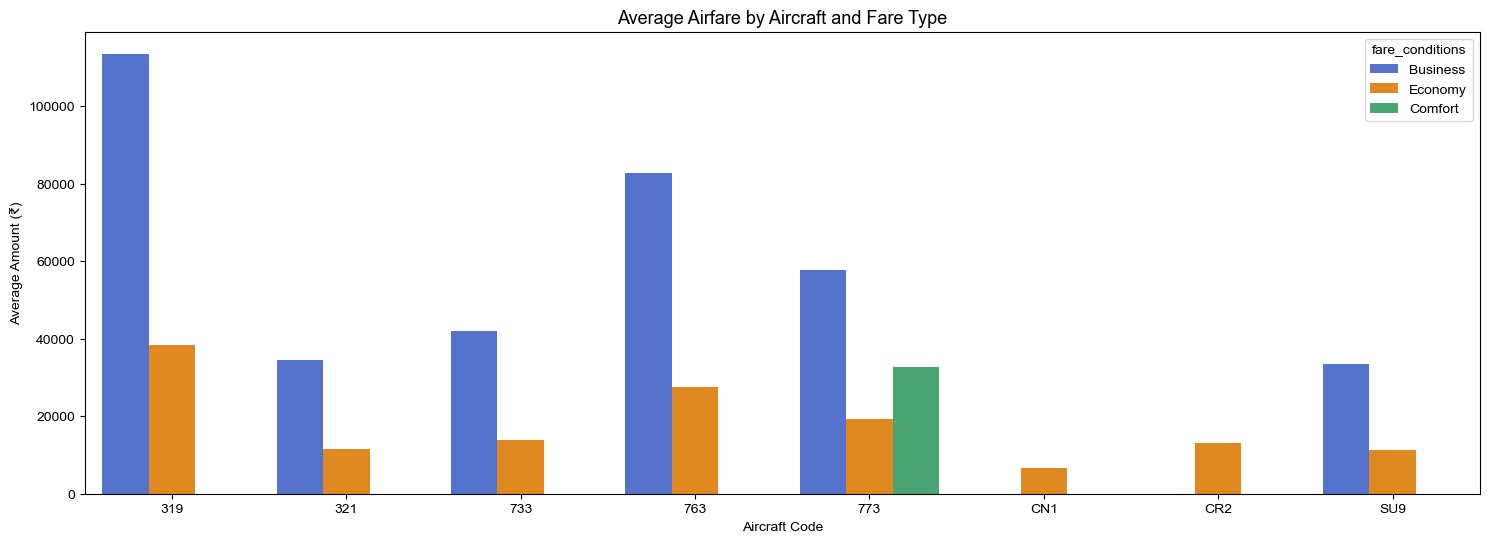

In [23]:
plt.figure(figsize=(18,6))
palette = {'Business': 'royalblue', 'Economy': 'darkorange', 'Comfort': 'mediumseagreen'}
sns.barplot(data=df_air_avg_charges, x='aircraft_code', y='avg(amount)', hue='fare_conditions', palette=palette)
plt.title('Average Airfare by Aircraft and Fare Type', fontsize=13)
plt.xlabel('Aircraft Code')
plt.ylabel('Average Amount (₹)')
sns.set_style("whitegrid")  # Options: 'darkgrid', 'white', 'ticks'


# Analysing Occupancy Rate

##### For each aircraft, calculate the total revenue per year and the average revenue per ticket.

In [28]:
pd.read_sql_query(""" SELECT aircraft_code, ticket_count, total_revenue, total_revenue/ticket_count AS Avg_revenue_per_ticket FROM

(SELECT aircraft_code, count(*) as ticket_count, sum(amount) as total_revenue FROM ticket_flights as tf INNER JOIN flights as f
                        ON tf.flight_id = f.flight_id
                            group by aircraft_code)""",data_connect)

,aircraft_code,ticket_count,total_revenue,Avg_revenue_per_ticket
0,319,52853,2706163100,51201
1,321,107129,1638164100,15291
2,733,86102,1426552100,16568
3,763,124774,4371277100,35033
4,773,144376,3431205500,23765
5,CN1,14672,96373800,6568
6,CR2,150122,1982760500,13207
7,SU9,365698,5114484700,13985


##### Calculate the average occupancy per aircraft.

In [45]:
# Query 1 - to get seat counts per flight
query_1 = pd.read_sql_query("""SELECT aircraft_code, flights.flight_id, count(*) as seat_count FROM boarding_passes 
                            INNER JOIN flights 
                            ON boarding_passes.flight_id = flights.flight_id
                            GROUP BY aircraft_code, flights.flight_id""",data_connect)

#Query 2 - to get total number of seats per aircraft
query_2 = pd.read_sql_query("""SELECT aircraft_code, count(*) as num_seats FROM seats
                            GROUP BY aircraft_code""",data_connect)

# Merging Query 1 and Query 2 on aircraft code
merged_query = pd.merge(query_1, query_2,  on='aircraft_code')
merged_query

,aircraft_code,flight_id,seat_count,num_seats
0,319,1162,51,116
1,319,1166,54,116
2,319,1167,57,116
3,319,1168,60,116
4,319,1170,58,116
...,...,...,...,...
11513,SU9,32925,12,97
11514,SU9,32928,25,97
11515,SU9,32931,12,97
11516,SU9,32933,16,97


In [64]:
occupancy_summary = merged_query.groupby('aircraft_code').agg({
    'seat_count':'mean',
    'num_seats':'first'
}).reset_index()
occupancy_summary

,aircraft_code,seat_count,num_seats
0,319,53.583181,116
1,321,88.809231,170
2,733,80.255462,130
3,763,113.937294,222
4,773,264.925806,402
5,CN1,6.004431,12
6,CR2,21.482847,50
7,SU9,56.812113,97


In [65]:
occupancy_summary['Avg_occupancy_rate']=(occupancy_summary['seat_count']/occupancy_summary['num_seats'])*100
occupancy_summary

,aircraft_code,seat_count,num_seats,Avg_occupancy_rate
0,319,53.583181,116,46.192397
1,321,88.809231,170,52.240724
2,733,80.255462,130,61.734971
3,763,113.937294,222,51.323105
4,773,264.925806,402,65.901942
5,CN1,6.004431,12,50.036928
6,CR2,21.482847,50,42.965694
7,SU9,56.812113,97,58.569188


##### Calculate by how much the total annual turnover could increase by giving all aircraft a 10% higher occupancy rate.

In [73]:
occupancy_summary['Inc Occupancy Rate 10_percent'] = occupancy_summary['Avg_occupancy_rate']+occupancy_summary['Avg_occupancy_rate']*0.1
occupancy_summary

,aircraft_code,seat_count,num_seats,Avg_occupancy_rate,Inc Occupancy Rate 10_percent
0,319,53.583181,116,46.192397,50.811637
1,321,88.809231,170,52.240724,57.464796
2,733,80.255462,130,61.734971,67.908468
3,763,113.937294,222,51.323105,56.455416
4,773,264.925806,402,65.901942,72.492136
5,CN1,6.004431,12,50.036928,55.040620
6,CR2,21.482847,50,42.965694,47.262263
7,SU9,56.812113,97,58.569188,64.426107


In [74]:
total_revenue = pd.read_sql_query("""SELECT aircraft_code, sum(amount) as total_revenue from ticket_flights as tf
                JOIN flights as f
                ON tf.flight_id=f.flight_id
                GROUP BY aircraft_code""",data_connect)
total_revenue

,aircraft_code,total_revenue
0,319,2706163100
1,321,1638164100
2,733,1426552100
3,763,4371277100
4,773,3431205500
5,CN1,96373800
6,CR2,1982760500
7,SU9,5114484700


In [76]:
occupancy_summary['Inc Total Revenue Turnover 10_percent'] = (total_revenue['total_revenue']/occupancy_summary['Avg_occupancy_rate']) * occupancy_summary['Inc Occupancy Rate 10_percent']
occupancy_summary

,aircraft_code,seat_count,num_seats,Avg_occupancy_rate,Inc Occupancy Rate 10_percent,Inc Total Revenue Turnover 10_percent
0,319,53.583181,116,46.192397,50.811637,2.976779e+09
1,321,88.809231,170,52.240724,57.464796,1.801981e+09
2,733,80.255462,130,61.734971,67.908468,1.569207e+09
3,763,113.937294,222,51.323105,56.455416,4.808405e+09
4,773,264.925806,402,65.901942,72.492136,3.774326e+09
5,CN1,6.004431,12,50.036928,55.040620,1.060112e+08
6,CR2,21.482847,50,42.965694,47.262263,2.181037e+09
7,SU9,56.812113,97,58.569188,64.426107,5.625933e+09
